In [1]:
%matplotlib ipympl

In [2]:
import numpy as np
import scipy.constants as const

# 1. Define physical constants and conversion factors
h = const.h                      # Planck constant in J*s
e = const.e                      # Elementary charge in C
Phi0 = h / (2 * e)               # Magnetic flux quantum in Wb
GHz = 1e9                        # Conversion for Hz to GHz
fF_to_F = 1e-15                  # femtoFarad to Farad

# 2. Define input parameters
fp_target_GHz = 30          # Target plasma frequency in GHz
wp_target = 2 * np.pi * fp_target_GHz * GHz # Target angular frequency in rad/s

# Junction dimensions
W_um = 0.6                       # Width in um (200 nm)
L_um = 2.0                       # Length in um
N = 120                 # number of cells
# for N in [120]:

C_area_fF_per_um2 = 45.0         # Capacitance per unit area in fF/um^2 (Assumed)

# 3. Calculate Junction Capacitance (C_J)
Area_um2 = W_um * L_um
CJ = C_area_fF_per_um2 * Area_um2 * fF_to_F # Junction capacitance C in Farads (F)

# 4. Calculate Josephson Inductance (L_J)
# Formula: wp = 1/sqrt(LJ * CJ) => LJ = 1 / (wp^2 * CJ)
LJ = 1.0 / (wp_target**2 * CJ)  # Josephson Inductance L in Henries (H)

# 5. Calculate Josephson Energy (E_J)
# Formula: EJ = (Phi0 / (2*pi))^2 / LJ
EJ = (Phi0 / (2 * np.pi))**2 / LJ # Josephson Energy EJ in Joules (J)
EJ_GHz = EJ / h  / GHz                # Josephson Energy EJ in GHz

# 6. Calculate Charging Energy (E_C)
# Formula: EC = e^2 / (2 * (2 * CJ))
EC = e**2 / (2 * CJ)             # Charging Energy EC in Joules (J)
EC_GHz = EC / h  / GHz                  # Charging Energy EC in GHz


# Cg_over_CJ = 0.10       # stray-to-ground ratio
Cg = 20e-18 ###Cg_over_CJ * CJ

# --- Chain design targets (edit here) ---
a = W_um * 1e-6                # cell pitch [m] (for bookkeeping; not critical here)


#########################################
R = 50.0                       # target wave impedance [Ohm]
d = 0.1

Phi_ext = 0.5*Phi0


Cc = 1.5e-15             # [F]


Bare qubit frequency [GHz] = 9.486832980505143


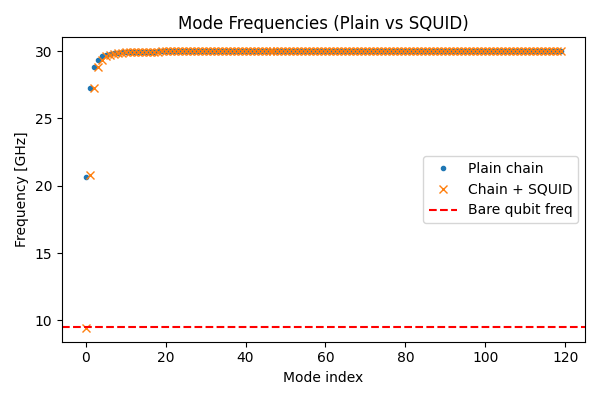

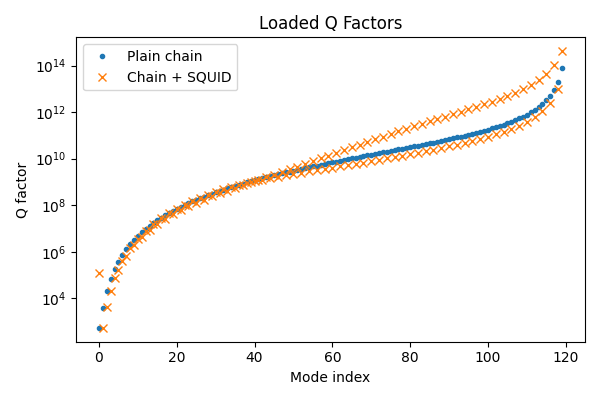

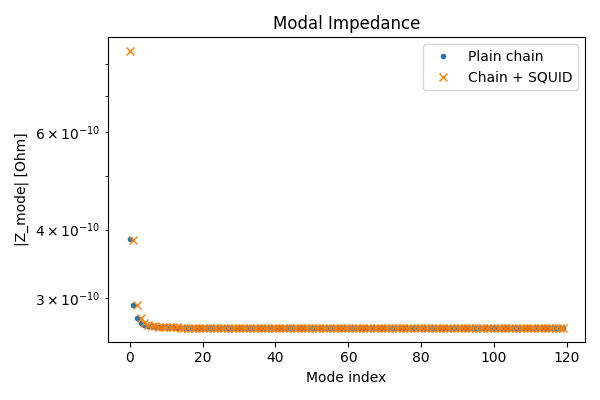

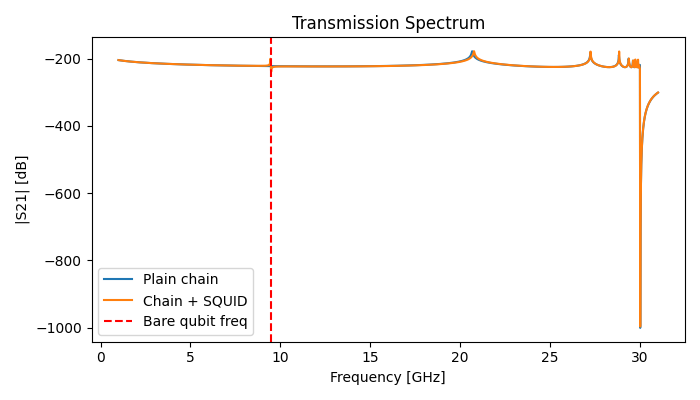

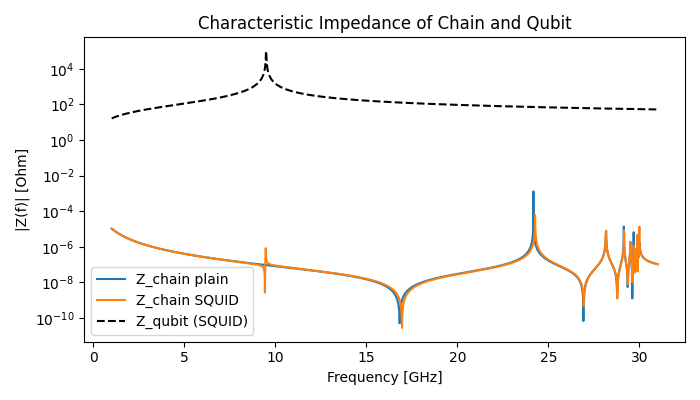

In [3]:
import numpy as np
from numpy.linalg import inv, eig
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.constants as const

###############################################################################
# 0. CONSTANTS
###############################################################################

Phi0 = 2.067833848e-15   # flux quantum


###############################################################################
# 1. SQUID EFFECTIVE PARAMETERS
###############################################################################

def squid_EJ_eff(EJ, d, Phi_ext):
    """
    Compute effective EJ of an asymmetric SQUID at external flux Phi_ext.
    EJ = average Josephson energy
    d = asymmetry (0..1)
    """
    EJ1 = EJ*(1+d)
    EJ2 = EJ*(1-d)
    return np.sqrt(EJ1**2 + EJ2**2 + 2*EJ1*EJ2*np.cos(2*np.pi*Phi_ext/Phi0))


def squid_LJ(EJ_eff):
    return Phi0**2/(4*np.pi**2 * EJ_eff)


def squid_CJ(CJ):
    # Capacitance model B → 2CJ
    return 2*CJ


def squid_bare_frequency(EJ, CJ, d, Phi_ext):
    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    L = squid_LJ(EJ_eff)
    C = squid_CJ(CJ)
    return 1/(2*np.pi*np.sqrt(L*C))


###############################################################################
# 2. BUILD MATRIX FOR PLAIN CHAIN
###############################################################################

def build_chain_plain(N, LJ, CJ, Cg, Cc, R):
    n_nodes = N + 2
    K = np.zeros((n_nodes, n_nodes))
    C = np.zeros((n_nodes, n_nodes))
    G = np.zeros((n_nodes, n_nodes))

    # JJs
    for j in range(1, N+1):
        i1, i2 = j, j+1
        val = 1/LJ
        K[i1,i1]+=val; K[i2,i2]+=val
        K[i1,i2]-=val; K[i2,i1]-=val

    # JJ capacitances
    for j in range(1, N+1):
        i1, i2 = j, j+1
        C[i1,i1]+=CJ; C[i2,i2]+=CJ
        C[i1,i2]-=CJ; C[i2,i1]-=CJ

    # shunt Cg
    for k in range(2, N+2):
        C[k,k]+=Cg

    # port coupling
    C[0,0]+=Cc; C[1,1]+=Cc
    C[0,1]-=Cc; C[1,0]-=Cc

    # feedline damping
    G[0,0]=1/R
    return K, C, G


###############################################################################
# 3. BUILD MATRIX FOR CHAIN WITH A SQUID BETWEEN N_SQUID and N_SQUID+1
###############################################################################

def build_chain_squid(N, LJ, CJ, Cg, Cc, R, EJ, d, Phi_ext, N_SQUID=None):
    if N_SQUID is None:
        N_SQUID = N - 3

    # SQUID effective params
    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    LJ_s = squid_LJ(EJ_eff)
    CJ_s = squid_CJ(CJ)

    n_nodes = N+2
    K = np.zeros((n_nodes, n_nodes))
    C = np.zeros((n_nodes, n_nodes))
    G = np.zeros((n_nodes, n_nodes))

    # Inductors, but SQUID replaces one
    for j in range(1, N+1):
        i1, i2 = j, j+1
        if j == N_SQUID:
            val = 1/LJ_s
        else:
            val = 1/LJ
        K[i1,i1]+=val; K[i2,i2]+=val
        K[i1,i2]-=val; K[i2,i1]-=val

    # JJ capacitances, but SQUID capacitance at its location
    for j in range(1, N+1):
        i1, i2 = j, j+1
        if j == N_SQUID:
            CJ_eff = CJ_s
        else:
            CJ_eff = CJ
        C[i1,i1]+=CJ_eff; C[i2,i2]+=CJ_eff
        C[i1,i2]-=CJ_eff; C[i2,i1]-=CJ_eff

    # shunt Cg
    for k in range(2, N+2):
        C[k,k]+=Cg

    # port coupling
    C[0,0]+=Cc; C[1,1]+=Cc
    C[0,1]-=Cc; C[1,0]-=Cc

    # feed damping
    G[0,0]=1/R

    return K, C, G, N_SQUID, LJ_s, CJ_s


###############################################################################
# 4. UNIVERSAL SOLVERS
###############################################################################

def build_A(K, C, G):
    n = C.shape[0]
    Cinv = inv(C)
    zero = np.zeros((n,n))
    I = np.eye(n)
    A_top = np.hstack([zero, I])
    A_bot = np.hstack([-Cinv@K, -Cinv@G])
    return np.vstack([A_top, A_bot])


def compute_modes(A):
    lam, vec = eig(A)
    mask = np.where(np.imag(lam)>0)[0]
    lam = lam[mask]; vec = vec[:,mask]

    order = np.argsort(np.imag(lam))
    lam = lam[order]; vec = vec[:,order]

    omega = np.imag(lam)
    kappa = -np.real(lam)
    freqs = omega/(2*np.pi)
    Q = omega/(2*kappa)
    return freqs, Q, lam, vec


def compute_mode_impedances(freqs, modes, Cc, R):
    n_modes = len(freqs)
    Z = []
    for j in range(n_modes):
        f = freqs[j]
        w = 2*np.pi*f
        mode = modes[:,j]
        n = len(mode)//2
        phi = mode[:n]
        phi0 = phi[0]
        phi1 = phi[1]
        I = 1j*w*(phi0/R + Cc*(phi0 - phi1))
        Z.append(phi0/I)
    return np.array(Z)


def s21(K,C,G,Cc,R,freqs):
    n = C.shape[0]
    S = []
    b = np.zeros(n); b[0]=1/R
    for f in freqs:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G
        phi = np.linalg.solve(M,b)
        S.append(phi[-1])
    return np.array(S)


###############################################################################
# 5. COMPARISON PLOTS
###############################################################################

def compare_modes(freqs_plain, freqs_squid, f_q):
    plt.figure(figsize=(6,4))
    plt.plot(freqs_plain/1e9, '.', label='Plain chain')
    plt.plot(freqs_squid/1e9, 'x', label='Chain + SQUID')
    plt.axhline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Mode index")
    plt.ylabel("Frequency [GHz]")
    plt.legend()
    plt.title("Mode Frequencies (Plain vs SQUID)")
    plt.tight_layout()
    plt.show()


def compare_Q(Q_plain, Q_squid):
    plt.figure(figsize=(6,4))
    plt.plot(Q_plain, '.', label='Plain chain')
    plt.plot(Q_squid, 'x', label='Chain + SQUID')
    plt.yscale('log')
    plt.xlabel("Mode index")
    plt.ylabel("Q factor")
    plt.legend()
    plt.title("Loaded Q Factors")
    plt.tight_layout()
    plt.show()


def compare_Z(Z_plain, Z_squid):
    plt.figure(figsize=(6,4))
    plt.semilogy(np.abs(Z_plain), '.', label='Plain chain')
    plt.semilogy(np.abs(Z_squid), 'x', label='Chain + SQUID')
    plt.xlabel("Mode index")
    plt.ylabel("|Z_mode| [Ohm]")
    plt.legend()
    plt.title("Modal Impedance")
    plt.tight_layout()
    plt.show()


def compare_S21(fspan, S_plain, S_squid, f_q):
    plt.figure(figsize=(7,4))
    plt.plot(fspan/1e9, 20*np.log10(np.abs(S_plain)), label='Plain chain')
    plt.plot(fspan/1e9, 20*np.log10(np.abs(S_squid)), label='Chain + SQUID')
    plt.axvline(f_q/1e9, color='r', linestyle='--', label='Bare qubit freq')
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("|S21| [dB]")
    plt.legend()
    plt.title("Transmission Spectrum")
    plt.tight_layout()
    plt.show()


###############################################################################
# 9. CHARACTERISTIC IMPEDANCE FUNCTIONS
###############################################################################

def Z_chain_frequency(K, C, G, fspan, node_in=1):
    """
    Compute the input impedance looking into the chain at node `node_in`.
    Feedline is removed (use K,C,G from the full system but zero out shunt R).

    Z_chain(f) = V(node_in)/I(node_in)
    where we inject 1A current into node_in and compute voltage response.
    """
    # Remove feedline loss: zero out G[0,0]
    G2 = G.copy()
    G2[0,0] = 0.0

    Z = []
    n = C.shape[0]

    # Drive vector: current injection at node_in
    b = np.zeros(n)
    b[node_in] = 1.0

    for f in fspan:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G2
        phi = np.linalg.solve(M, b)
        Z.append(phi[node_in])   # since current = 1A
    return np.array(Z)


def Z_qubit_frequency(EJ, CJ, d, Phi_ext, fspan):
    """
    Linearized qubit/squid impedance:
        Z(q) = i*w*L / (1 - w^2 L C)
    where:
        L = LJ(EJ_eff)
        C = 2 CJ (cap model B)
    """
    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    L = squid_LJ(EJ_eff)
    C = squid_CJ(CJ)

    Zq = []
    for f in fspan:
        w = 2*np.pi*f
        denom = (1 - w*w*L*C)
        Z = 1j*w*L / denom
        Zq.append(Z)
    return np.array(Zq)

def plot_Z_chain_and_qubit(fspan, Z_chain_plain, Z_chain_squid, Zq):
    plt.figure(figsize=(7,4))
    plt.semilogy(fspan/1e9, np.abs(Z_chain_plain), label='Z_chain plain')
    plt.semilogy(fspan/1e9, np.abs(Z_chain_squid), label='Z_chain SQUID')
    plt.semilogy(fspan/1e9, np.abs(Zq), 'k--', label='Z_qubit (SQUID)')
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("|Z(f)| [Ohm]")
    plt.legend()
    plt.title("Characteristic Impedance of Chain and Qubit")
    plt.tight_layout()
    plt.show()


###############################################################################




###############################################################################
# 6. MAIN (example usage)
###############################################################################



EJ = Phi0**2/(4*np.pi**2 * LJ)   # Convert LJ → EJ
N_SQUID = N//2 #N-3

# Bare SQUID/transmon frequency
f_q = squid_bare_frequency(EJ, CJ, d, Phi_ext)
print("Bare qubit frequency [GHz] =", f_q/1e9)

# Plain chain
Kp, Cp, Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
Ap = build_A(Kp, Cp, Gp)
freqs_plain, Q_plain, lam_p, modes_plain = compute_modes(Ap)
Z_plain = compute_mode_impedances(freqs_plain, modes_plain, Cc, R)

# Chain with SQUID
Ks, Cs, Gs, N_SQUID, LJ_s, CJ_s = build_chain_squid(
    N, LJ, CJ, Cg, Cc, R, EJ, d, Phi_ext, N_SQUID)
As = build_A(Ks, Cs, Gs)
freqs_squid, Q_squid, lam_s, modes_squid = compute_modes(As)
Z_squid = compute_mode_impedances(freqs_squid, modes_squid, Cc, R)

# Frequency sweeps
fspan = np.linspace(1e9, 31e9, 2000)#np.linspace(1e9, 25e9, 2000)
S_plain = s21(Kp, Cp, Gp, Cc, R, fspan)
S_squid = s21(Ks, Cs, Gs, Cc, R, fspan)

# Plots
compare_modes(freqs_plain, freqs_squid, f_q)
compare_Q(Q_plain, Q_squid)
compare_Z(Z_plain, Z_squid)
compare_S21(fspan, S_plain, S_squid, f_q)

# Compute characteristic impedances
Z_chain_plain = Z_chain_frequency(Kp, Cp, Gp, fspan)
Z_chain_squid = Z_chain_frequency(Ks, Cs, Gs, fspan)
Z_q = Z_qubit_frequency(EJ, CJ, d, Phi_ext, fspan)

plot_Z_chain_and_qubit(fspan, Z_chain_plain, Z_chain_squid, Z_q)






================= PURCELL RESULTS ==================
Qubit frequency: 18.506 GHz
Y_env: (29480449.91591262+298361.3623128089j)

---- CAPACITIVE PURCELL ----
n01 = -1.796e+00
Q_zpf = 3.268e-21 C
Gamma_C = 2.238e+12 1/s
T1_C = 0.000 us

---- INDUCTIVE PURCELL ----
phi01 = 1.034e-15 Wb
phi_zpf = 1.614e-14 Wb
Gamma_L = 1.810e-05 1/s
T1_L = 55257507775.697 us


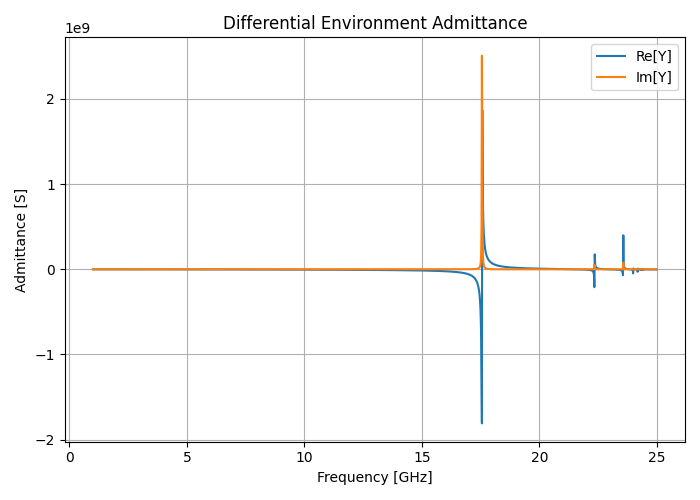

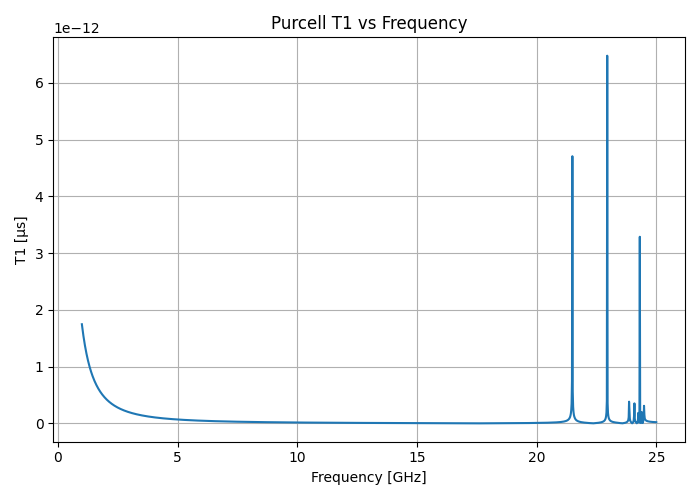

In [23]:
###############################################################################
# FULL PHYSICALLY-CORRECT JJ CHAIN + SQUID TRANSMON + PURCELL SIMULATION
# BOTH PURCELL CHANNELS:
#   (A) Capacitive Purcell via n-operator
#   (B) Inductive Purcell via reconstructed φ-operator
#
# UNITS CHECKED, OPERATORS FIXED, ZPF CORRECT, EJ/EC CONVERSIONS FIXED
###############################################################################

import numpy as np
import scipy.constants as const
from numpy.linalg import inv
import matplotlib.pyplot as plt
import scqubits as scq

###############################################################################
# CONSTANTS
###############################################################################

Phi0 = const.h / (2*const.e)       # flux quantum [Wb]
hbar  = const.hbar


###############################################################################
# CHAIN BUILDERS
###############################################################################

def build_chain_squid(N, LJ, CJ, Cg, Cc, R, N_SQUID):
    """
    Build capacitance, inductance (stiffness), and damping matrices
    for a JJ chain where one JJ (node N_SQUID ↔ N_SQUID+1) is replaced
    by the transmon/SQUID qubit.
    """
    n_nodes = N + 2
    K = np.zeros((n_nodes, n_nodes))
    C = np.zeros((n_nodes, n_nodes))
    G = np.zeros((n_nodes, n_nodes))

    # JJs everywhere except the SQUID location
    for j in range(1, N+1):
        if j == N_SQUID:
            continue
        i1, i2 = j, j+1
        valL = 1 / LJ
        K[i1,i1] += valL
        K[i2,i2] += valL
        K[i1,i2] -= valL
        K[i2,i1] -= valL

        C[i1,i1] += CJ
        C[i2,i2] += CJ
        C[i1,i2] -= CJ
        C[i2,i1] -= CJ

    # Shunt Cg to ground
    for k in range(2, N+2):
        C[k,k] += Cg

    # Port coupling capacitor
    C[0,0] += Cc
    C[1,1] += Cc
    C[0,1] -= Cc
    C[1,0] -= Cc

    # Load resistance
    G[0,0] = 1/R

    return K, C, G


###############################################################################
# SYSTEM SOLVER – DIFFERENTIAL ADMITTANCE
###############################################################################

def Y_environment_differential(K, C, G, f, node_L, node_R):
    w = 2*np.pi*f
    M = K - w*w*C + 1j*w*G
    b = np.zeros(K.shape[0], dtype=complex)
    b[node_L] = +1
    b[node_R] = -1
    phi = np.linalg.solve(M, b)
    Vdiff = phi[node_L] - phi[node_R]
    return 1 / Vdiff


###############################################################################
# TRANSMON BUILDING
###############################################################################

def build_transmon(EJmax_GHz, EC_GHz, d, flux):
    """
    Tunable transmon using scqubits.
    All internal Hamiltonian work in ħω units (GHz).
    """
    return scq.TunableTransmon(
        EJmax=EJmax_GHz,
        EC=EC_GHz,
        ng=0.0,
        d=d,
        flux=flux,
        ncut=40,
        truncated_dim=8
    )


###############################################################################
# OPERATOR HELPERS
###############################################################################

def harmonic_Zpf(EJ_Hz, EC_Hz):
    """
    Compute ZPF of transmon harmonic mode using:
        L = Phi0^2 / (4π^2 EJ)
        C = e^2 / (2 EC)
    EJ_Hz, EC_Hz are in Hz.
    """
    EJ_J = EJ_Hz * const.h     # convert to J
    EC_J = EC_Hz * const.h
    L = Phi0**2 / (4*np.pi*np.pi * EJ_J)
    C = const.e**2 / (2*EC_J)
    Zq = np.sqrt(L/C)
    phi_zpf = np.sqrt(hbar*Zq/2)
    Q_zpf   = np.sqrt(hbar/(2*Zq))
    return phi_zpf, Q_zpf, Zq


###############################################################################
# PURCELL CHANNEL A – CAPACITIVE (via n)
###############################################################################

def purcell_capacitive(qubit, Y_env, f_q):
    evals, evecs = qubit.eigensys()
    n_op = qubit.n_operator()

    n01 = (evecs[:,0].conj().T @ n_op @ evecs[:,1]).item()

    # EJ, EC in Hz for harmonic ZPF
    EJ_Hz = qubit.EJ
    EC_Hz = qubit.EC * 1e9
    _, Q_zpf, Zq = harmonic_Zpf(EJ_Hz, EC_Hz)

    w_q = 2*np.pi*f_q
    Gamma = (2*w_q/hbar) * (Q_zpf**2) * abs(n01)**2 * np.real(Y_env)

    return Gamma.real, n01, Q_zpf, Zq


###############################################################################
# PURCELL CHANNEL B – INDUCTIVE (via φ)
###############################################################################

def purcell_inductive(qubit, Y_env, f_q):
    evals, evecs = qubit.eigensys()

    # exp(iφ) operator from scqubits
    U  = qubit.exp_i_phi_operator()
    Up = U.conj().T

    cosphi = (U + Up)/2
    sinphi = (U - Up)/(2j)

    # Rotate into eigenbasis
    cos_e = evecs.T.conj() @ cosphi @ evecs
    sin_e = evecs.T.conj() @ sinphi @ evecs

    cos01 = cos_e[0,1]
    sin01 = sin_e[0,1]

    # phase matrix element (small-angle approx)
    varphi01 = np.arctan2(sin01.real, cos01.real)

    # convert reduced phase → flux
    phi01 = (Phi0/(2*np.pi)) * varphi01

    # Compute ZPF
    EJ_Hz = qubit.EJ
    EC_Hz = qubit.EC * 1e9
    phi_zpf, _, Zq = harmonic_Zpf(EJ_Hz, EC_Hz)

    w_q = 2*np.pi*f_q
    Gamma = (2*w_q/hbar) * (phi_zpf**2) * abs(phi01)**2 * np.real(Y_env)

    return Gamma.real, phi01, phi_zpf, Zq


###############################################################################
# TOP-LEVEL PURCELL COMPUTATION
###############################################################################

def compute_purcell(K, C, G,
                    EJmax_GHz, EC_GHz, d, flux,
                    node_L, node_R):
    qubit = build_transmon(EJmax_GHz, EC_GHz, d, flux)
    evals, _ = qubit.eigensys()

    # scqubits eigenvalues are in GHz → convert to Hz
    f_q = (evals[1] - evals[0]) * 1e9

    # environment admittance at qubit frequency
    Y_env = Y_environment_differential(K, C, G, f_q, node_L, node_R)

    # PURCELL CHANNEL A
    Gamma_C, n01, Q_zpf, Zq_C = purcell_capacitive(qubit, Y_env, f_q)

    # PURCELL CHANNEL B
    Gamma_L, phi01, phi_zpf, Zq_L = purcell_inductive(qubit, Y_env, f_q)


    return {
        "f_q_Hz": f_q,
        "Y_env": Y_env,

        # Capacitive
        "Gamma_C": Gamma_C,
        "T1_C": 1/Gamma_C if Gamma_C>0 else np.inf,
        "n01": n01,
        "Q_zpf": Q_zpf,
        "Zq_C": Zq_C,

        # Inductive
        "Gamma_L": Gamma_L,
        "T1_L": 1/Gamma_L if Gamma_L>0 else np.inf,
        "phi01": phi01,
        "phi_zpf": phi_zpf,
        "Zq_L": Zq_L,
    }


###############################################################################
# EXTRA PLOTS:  Y(ω)  AND  T1(Φ)
###############################################################################








###############################################################################
# MAIN EXAMPLE
###############################################################################

if __name__ == "__main__":

    # ----------- chain parameters ------------
    N  = 120
    LJ = 7.8147364248e-10
    CJ = 5.4e-14
    Cg = 20e-18
    Cc = 1e-15
    R  = 50.0

    N_SQUID = N//2

    # ----------- transmon parameters ----------
    EJ_J = Phi0**2 / (4*np.pi*np.pi * LJ)
    EJmax_GHz = EJ_J / const.h / 1e9

    EC_J = const.e**2/(2*CJ)
    EC_GHz = EC_J / const.h / 1e9

    d = 0.1
    flux = 0.3  # Φ/Φ0

    # ----------- build chain ------------------
    K, C, G = build_chain_squid(N, LJ, CJ, Cg, Cc, R, N_SQUID)

    # ----------- Purcell ----------------------
    res = compute_purcell(
        K, C, G,
        EJmax_GHz, EC_GHz, d, flux,
        node_L=N_SQUID, node_R=N_SQUID+1
    )

    print("\n================= PURCELL RESULTS ==================")
    print(f"Qubit frequency: {res['f_q_Hz']/1e9:.3f} GHz")
    print(f"Y_env: {res['Y_env']}")
    print("\n---- CAPACITIVE PURCELL ----")
    print(f"n01 = {res['n01']:.3e}")
    print(f"Q_zpf = {res['Q_zpf']:.3e} C")
    print(f"Gamma_C = {res['Gamma_C']:.3e} 1/s")
    print(f"T1_C = {res['T1_C']*1e6:.3f} us")

    print("\n---- INDUCTIVE PURCELL ----")
    print(f"phi01 = {res['phi01']:.3e} Wb")
    print(f"phi_zpf = {res['phi_zpf']:.3e} Wb")
    print(f"Gamma_L = {res['Gamma_L']:.3e} 1/s")
    print(f"T1_L = {res['T1_L']*1e6:.3f} us")

    # ---- PLOT Y(ω) ----
    fspan = np.linspace(1e9, 25e9, 1500)
    Yvals = np.zeros_like(fspan, dtype=complex)

    for i, f in enumerate(fspan):
        Yvals[i] = Y_environment_differential(K, C, G, f, N_SQUID, N_SQUID+1)

    plt.figure(figsize=(7,5))
    plt.plot(fspan/1e9, np.real(Yvals), label='Re[Y]')
    plt.plot(fspan/1e9, np.imag(Yvals), label='Im[Y]')
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("Admittance [S]")
    plt.title("Differential Environment Admittance")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
    T1 = abs(1/np.real(Yvals) * CJ)

    plt.figure(figsize=(7,5))
    plt.plot(fspan/1e9, T1*1e6)
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("T1 [µs]")
    plt.title("Purcell T1 vs Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()





100%|██████████| 121/121 [00:40<00:00,  2.98it/s]


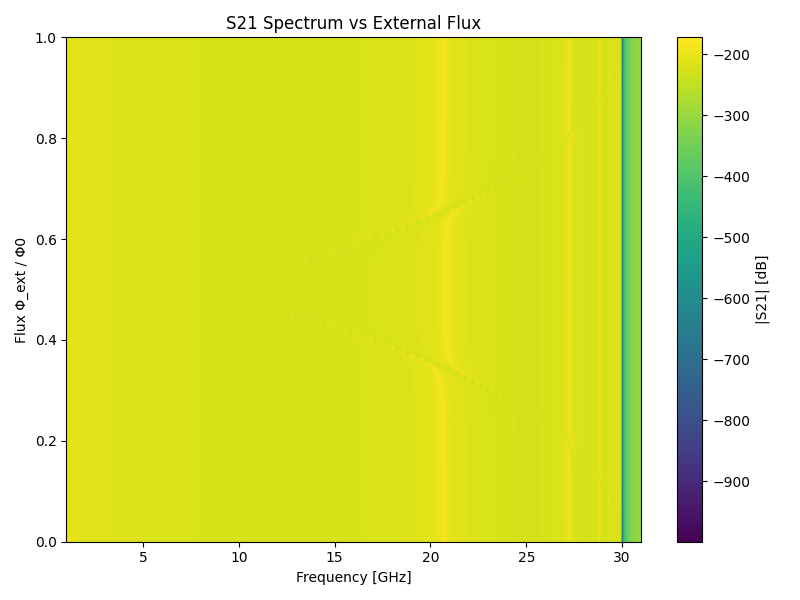

In [4]:
from tqdm import tqdm

###############################################################################
# S21 vs Flux Spectrum
###############################################################################
# This cell assumes that:
#   - build_chain_squid(...)
#   - s21(...)
#   - parameters EJ, CJ, d, N, LJ, Cg, Cc, R
#   - fspan already defined
# exist in the namespace above.

# Sweep parameters
Phi_values = np.linspace(0, 1.0*Phi0, 121)   # 0 → 1 Φ0, 121 steps
S21_flux_map = np.zeros((len(Phi_values), len(fspan)), dtype=complex)

for i, Phi_ext in enumerate(tqdm(Phi_values)):
    # build matrices for each flux
    Ks, Cs, Gs, N_SQ, LJ_s, CJ_s = build_chain_squid(
        N, LJ, CJ, Cg, Cc, R,
        EJ=EJ, d=d, Phi_ext=Phi_ext,
        N_SQUID=N_SQUID
    )
    # compute S21
    S21_flux_map[i, :] = s21(Ks, Cs, Gs, Cc, R, fspan)


###############################################################################
# Plot as colormap: |S21| vs f vs Flux
###############################################################################
plt.figure(figsize=(8,6))
extent = [fspan[0]/1e9, fspan[-1]/1e9, Phi_values[0]/Phi0, Phi_values[-1]/Phi0]

plt.imshow(
    20*np.log10(np.abs(S21_flux_map)),
    aspect='auto',
    origin='lower',
    extent=extent,
    cmap='viridis'
)



plt.colorbar(label='|S21| [dB]')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Φ_ext / Φ0')
plt.title('S21 Spectrum vs External Flux')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

###############################################################################
# Parameter sweeps
###############################################################################

Cc_values   = np.linspace(0.2e-15, 2.0e-15, 50)
Area_values = np.linspace(0.2,      2.0,     50)   # µm²
N_values    = np.arange(60, 160+1, 5)

# You can redefine:
# C_area_fF_per_um2 = 45.0
# Phi0, h, e from previous cell

###############################################################################
# FUNCTIONS FOR MODE EXTRACTION
###############################################################################

def extract_first_modes(freqs, threshold=1e9, num_modes=3):
    """
    Given an array of frequencies (Hz), return the FIRST num_modes modes
    that are above threshold (default=1 GHz).
    freqs are sorted already (because compute_modes sorts them).
    """
    good = freqs[freqs > threshold]
    if len(good) < num_modes:
        # Pad with NaNs if fewer modes
        padded = np.full(num_modes, np.nan)
        padded[:len(good)] = good
        return padded
    else:
        return good[:num_modes]


###############################################################################
# MAIN SWEEP
###############################################################################

# A place to store full results
# For each N, we will save a CSV: sweep_results_N{N}.csv
# Data columns: N, Cc, Area_um2, CJ, LJ, mode0, mode1, mode2 (GHz)

for N in tqdm(N_values, desc="Sweeping N values"):

    results = []

    # precompute N_start/mid/end for colormaps later
    # but we will fill these after the sweep for this N
    for Cc in tqdm(Cc_values, leave=False, desc=f"N={N}"):
        for Area_um2 in Area_values:

            # -- Compute CJ and LJ for this Area --
            CJ = C_area_fF_per_um2 * Area_um2 * 1e-15
            LJ = 1.0 / (wp_target**2 * CJ)
            # Josephson Energy
            EJ = (Phi0 / (2*np.pi))**2 / LJ

            # Build chain WITHOUT SQUID
            Kp, Cp, Gp = build_chain_plain(N, LJ, CJ, Cg, Cc, R)
            Ap = build_A(Kp, Cp, Gp)

            # Compute modes
            freqs_plain, Q_plain, lam_p, modes_plain = compute_modes(Ap)  # Hz

            # Extract first meaningful modes > 1 GHz
            modes_Hz = freqs_plain
            m0, m1, m2 = extract_first_modes(modes_Hz, threshold=1e9, num_modes=3)

            results.append({
                "N": N,
                "Cc": Cc,
                "Area_um2": Area_um2,
                "CJ": CJ,
                "LJ": LJ,
                "mode0_GHz": m0/1e9 if not np.isnan(m0) else np.nan,
                "mode1_GHz": m1/1e9 if not np.isnan(m1) else np.nan,
                "mode2_GHz": m2/1e9 if not np.isnan(m2) else np.nan,
            })

    # Convert to DataFrame, save to CSV
    df = pd.DataFrame(results)
    df.to_csv(f"sweep_results_N{N}.csv", index=False)
    print(f"Saved: sweep_results_N{N}.csv")



